In [1]:
from typing import List, Optional, TypedDict
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from enum import Enum
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
llm = ChatGroq(model_name=os.environ.get("MODEL_NAME"))

In [3]:
class RouteType(str, Enum):
    SHOPPING = "shopping"
    GENERAL = "general"

In [4]:
class ContextRoute(str, Enum):
    # Where should I get information from?
    SEARCH = "search"
    CONTEXT = "context"

In [5]:
class IntentType(str, Enum):
    SEARCH = "search"
    COMPARE = "compare"
    DETAILS = "details"
    RECOMMEND = "recommend"

class SizeOption(str, Enum):
    XS = "XS"
    S = "S"
    M = "M"
    L = "L"
    XL = "XL"
    XXL = "XXL"

class GenderOption(str, Enum):
    MALE = "male"
    FEMALE = "female"
    UNISEX = "unisex"

class SortOption(str, Enum):
    PRICE_ASC = "price_asc"
    PRICE_DESC = "price_desc"
    NEWEST = "newest"
    POPULAR = "popular"

In [6]:
class RouterModel(BaseModel):
    """
    Decide whether the query is a shopping query or a general query.
    """
    route: RouteType = Field(..., description="The route type for the query")

In [7]:
class ShoppingIntentModel(BaseModel):

    intent: IntentType = Field(..., description="Intent type for the shopping query")
    category: Optional[str] = Field(None, description="Category of the shopping item")
    product_name: Optional[str] = Field(None, description="Name of the product")
    color: Optional[str] = Field(None, description="Color of the product")
    material: Optional[str] = Field(None, description="Material of the product")
    size: Optional[SizeOption] = Field(None, description="Size of the product")
    fit: Optional[str] = Field(None,description="Fit of the clothing such as Slim Fit, Regular Fit, Oversized, Relaxed Fit") 
    brands: Optional[List[str]] = Field(None, description="List of preferred brands for the product")
    gender: Optional[GenderOption] = Field(None, description="Target gender of the product")
    # price_range: Optional[str] = Field(None, description="Price range of the product")
    price_min: Optional[int] = Field(None, description="Minimum price of the product")
    price_max: Optional[int] = Field(None, description="Maximum price of the product")
    sort: Optional[SortOption] = Field(None, description="Sorting preference for the product")
    occasion: Optional[str] = Field(None, description="Occasion for the product")

In [8]:
ROUTER_PROMPT = """
You are an AI router.

Your ONLY job is to classify the user's message.

Return ONLY valid JSON.

Routes:

shopping
general

Choose shopping if the user is:

- searching products
- asking product details
- asking price
- asking stock
- asking recommendation
- asking to compare products
- asking about clothing

Choose general if the user is:

- greeting
- casual conversation
- asking who you are
- thanking
- asking jokes
- asking unrelated questions

Examples:

Hi
→ general

Hello
→ general

How are you?
→ general

Who are you?
→ general

Show me blue shirts
→ shopping

Do you have black caps?
→ shopping

What's the cheapest shirt?
→ shopping

Recommend jeans
→ shopping
"""

In [9]:
INTENT_PROMPT = """
You are an AI shopping assistant.

Your ONLY task is to extract shopping intent.

Return ONLY valid JSON matching the provided schema.

Rules:

- Never answer the user.
- Never recommend products.
- Never explain anything.

Extract:

- intent
- category
- product_name
- color
- material
- size
- fit
- brand
- gender
- minimum price
- maximum price
- sorting preference
- occasion

Examples:

Cheapest jeans

↓

sort = "price_asc"

Products under ₹700

↓

price_max = 700

Blue cotton t-shirt

↓

category = "T-Shirt"

color = "Blue"

material = "Cotton"

Product name means the exact name of a specific product.

Do NOT copy the category into product_name.

Example:

"Blue T-Shirt"

category = "T-Shirt"
product_name = null

Example:

"Nike Air Max 90"

product_name = "Nike Air Max 90"
category = "Shoes"

If the query contains words like:
- cheap
- cheapest
- budget
- affordable
- low price
- lowest price
- inexpensive

Then set:

sort = "price_asc"

Intent Rules

If the user asks to:

recommend
suggest
show me something
give me ideas

intent = "recommend"

Size Rules:

Only use these values for size:
XS, S, M, L, XL, XXL.

Never put words like:
- Oversized
- Slim Fit
- Regular Fit
- Relaxed Fit

into the size field.

These belong in the fit field.

Examples:

"Oversized T-Shirt"

size = null
fit = "Oversized"

"Size M Hoodie"

size = "M"
fit = null

"Regular Fit Size L Shirt"

size = "L"
fit = "Regular Fit"

Available product categories are ONLY:

- T-Shirt
- Shirt
- Jeans
- Hoodie
- Shorts
- Shoes
- Cap
- Jacket
...

Available product categories:

- Shirt
- T-Shirt
- Jeans
- Shorts
- Hoodie
- Joggers
- Jacket
- Shoes
- Cap

Category Rules:

1. The category must be one of the categories listed above.
2. Do NOT invent categories.
3. Do NOT map or normalize categories.
4. If the requested category is not in the list (e.g. Polo, Kurta, Blazer), set category = null.
5. Preserve all other extracted information such as color, size, material, gender and price.
"""


In [10]:
RESPONSE_PROMPT = """
You are a helpful AI shopping assistant.

You will receive:

1. Customer query
2. Shopping intent
3. Products returned from the database

Rules:

- Use ONLY the provided product data.
- Never invent products.
- Never invent prices.
- Never invent stock.
- Never invent colors.
- Be friendly and concise.

If no products are found:
Politely say that no matching products were found.

If exactly one product is found:
Answer naturally using its details.

If multiple products are found:
Briefly summarize the products and mention a few of them.
"""

In [11]:
class ShoppingState(TypedDict):
    query: str = Field(..., description="User's shopping query")
    route: RouteType | None = Field(None, description="ROUTER_PROMPT result")
    context_route: ContextRoute = Field(..., description="Where to get information from: search or context")
    intent: ShoppingIntentModel | None = Field(None, description="Extracted shopping intent from the query")
    products: List[dict] | None = Field(None, description="List of products matching the shopping intent")
    response: str | None = Field(None, description="Response to the user based on the shopping intent and products")

In [12]:
def router(state: ShoppingState):

    query = state["query"]
    structured_llm = llm.with_structured_output(RouterModel)

    result = structured_llm.invoke(
        [
            ("system", ROUTER_PROMPT),
            ("human", query)
        ]
    )
    return {
        "route": result.route    }

In [13]:
def decide_route(state: ShoppingState):
    return state['route']

In [14]:
def load_history(config: RunnableConfig):
    # print("here load_history")

    # print(config["configurable"])

    # Build a clean config
    clean_config = {
        "configurable": {
            "thread_id": config["configurable"]["thread_id"]
        }
    }

    # print("Original:", config["configurable"].keys())
    # print("Clean:", clean_config)

    snapshots = list(workflow.get_state_history(clean_config))

    # print("Snapshots found:", len(snapshots))

    history = []
    seen = set()
    for snapshot in snapshots:
        # print(snapshot.values)      # temporary
        values = snapshot.values

    #     if values.get("query") and values.get("response"):
    #         history.append(values)

    # # print("History:", len(history))
    # return history
        if not values.get("query"):
            continue

        if not values.get("response"):
            continue

        key = (values["query"], values["response"])

        if key in seen:
            continue

        seen.add(key)
        history.append(values)
    return history

In [15]:
# later update
def general_chat(state: ShoppingState, config: RunnableConfig):
    # print("Workflow id:", id(workflow))
    # print("Memory id:", id(memory))
    # print(type(config))
    # print(config)
    # print(config["configurable"])

    history = load_history(config)

    history_text = build_conversation(history)

    prompt = f"""
You are a helpful AI assistant.

Below is the conversation history.

Use it to answer the current user's question.

If the user asks something like:
- What is my name?
- Which product did I ask about?
- What's its price?
- What color did I choose?

You MUST answer using the conversation history if the answer exists there.

Conversation History:
{history_text}

Current User:
{state["query"]}
"""

    # print("=" * 80)
    # print(prompt)
    # print("=" * 80)
    
    history = load_history(config)

    # print(history)

    history_text = build_conversation(history)

    # print(history_text)

    # print(config)

    # print("history =", history)
    from pprint import pprint

    print("=" * 80)
    print("HISTORY")
    pprint(history)
    print("=" * 80)
    response = llm.invoke(
    [
        (
            "system",
            "You are a helpful AI assistant. Use the previous conversation if it contains useful information."
        ),
        (
            "human",
            prompt
        )
    ]
)

    return {
        "response": response.content
    }

In [16]:
def build_conversation(history):
    """
    Covert LangGraph checkpoints into a clean conversation history
    """

    conversation = []
    seen_queries = set()

    for item in history:   # Newest -> Oldest
        
        query = item['query']

        if query in seen_queries:
            continue
        seen_queries.add(query)

        conversation.append(
            f"User: {query}\n"
            f"Assistant: {item['response']}"
        )

    conversation.reverse()  # Reverse to get Oldest -> Newest
    return "\n\n".join(conversation)  # join() simply combines all strings with two newlines between them.

In [17]:
def extract_intent(
        state: ShoppingState,
        config: RunnableConfig
    ) -> ShoppingState:
    """
    Extract shopping intent from the user's query using the ShoppingIntentModel.
    """

    history = load_history(config)
    history_text = build_conversation(history)

    query = state['query']
    ...
    structured_output = llm.with_structured_output(ShoppingIntentModel)

    system_prompt = INTENT_PROMPT + f"""
    Previous conversation:
    {history_text}

    If the current shopping question refers to
    a previous product using words like:

    - it
    - this
    - that
    - its
    - the product

    infer the product_name from the previous conversation.
    """

    print("=" * 80)
    print("SYSTEM PROMPT")
    print(system_prompt)
    print("=" * 80)

    print("USER QUERY")
    print(query)
    print("=" * 80)

    result = structured_output.invoke(
        [
            ("system", system_prompt),
            ("human", query)
        ]
    )

    

    return{
        "intent": result
    }

In [18]:
def context_decision(state: ShoppingState):
    """
    DEcide whether o seacrh the database or answer using conversation context
    """
    # print(state)
    intent = state['intent'].intent

    if intent in (
        IntentType.SEARCH,
        IntentType.DETAILS,
        IntentType.COMPARE,
        IntentType.RECOMMEND
    ):
        return {
            "context_route": ContextRoute.SEARCH
        }
    return {
        "context_route": ContextRoute.CONTEXT
    }
    # # imporve later
    # if (
    #     intent.category is None
    #     and intent.product_name is None
    #     and intent.color is None
    #     and intent.material is None
    #     and intent.size is None
    # ):
    #     return {
    #         "context_route": ContextRoute.CONTEXT
    #     }
    # return {
    #     "context_route": ContextRoute.SEARCH
    # }

In [19]:
def decide_context(state: ShoppingState):
    return state['context_route']

In [20]:
from supabase import create_client
load_dotenv(override=True)

supabase = create_client(
    os.getenv("SUPABASE_URL"),
    os.getenv("SUPABASE_KEY")
)

In [21]:
def search_product(state: ShoppingState) -> ShoppingState:
    """Query Supabase using the extracted shopping filters."""
    
    intent = state['intent']
    query = (
        supabase
        .table("products")
        .select("*")
    )

    if intent.product_name:
        query = query.ilike("name", f"%{intent.product_name}%")
        
    if intent.category:
        query = query.eq("category", intent.category)

    if intent.color:
        query = query.ilike("color", intent.color.capitalize())

    if intent.size:
        query = query.eq("size", intent.size)

    if intent.price_min is not None:
        query = query.gte("price", intent.price_min)
        
    if intent.price_max is not None:
        query = query.lte("price", intent.price_max)

    products = query.execute().data


    print(intent)
    print("Product Name:", intent.product_name)
    print("Category:", intent.category)
    print("Color:", intent.color)
    print("Size:", intent.size)
    print("Price Max:", intent.price_max)
    return {
        "products": products
    }

In [22]:
def generate_response(state: ShoppingState) -> ShoppingState:
    """Convert structured product data into a natural language reply."""
    products = state['products']

    prompt = f"""
Customer Query:
{state["query"]}

Shopping Intent:
{state["intent"]}

Products:
{products}
"""
    print(products[:2])
    response = llm.invoke(
        [
            ("system", RESPONSE_PROMPT),
            ("human", prompt)
        ]
    )

    return {
        "response": response.content
    }


In [23]:
graph = StateGraph(ShoppingState)

graph.add_node("router", router)
graph.add_node("general_chat", general_chat)
graph.add_node("extract_intent", extract_intent)
graph.add_node("context_decision", context_decision)
graph.add_node("search_products", search_product)
graph.add_node("generate_response", generate_response)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_route,
    {
        RouteType.SHOPPING: "extract_intent",
        RouteType.GENERAL: "general_chat",
    },
)

graph.add_edge("extract_intent", "context_decision")

graph.add_conditional_edges(
    "context_decision",
    decide_context,
    {
        ContextRoute.SEARCH: "search_products",
        ContextRoute.CONTEXT: "generate_response",
    },
)
graph.add_edge("search_products", "generate_response")
graph.add_edge("generate_response", END)


memory = InMemorySaver()
workflow = graph.compile(checkpointer=memory)
# workflow
workflow.get_graph().draw_mermaid()

'---\nconfig:\n  flowchart:\n    curve: linear\n---\ngraph TD;\n\t__start__([<p>__start__</p>]):::first\n\trouter(router)\n\tgeneral_chat(general_chat)\n\textract_intent(extract_intent)\n\tcontext_decision(context_decision)\n\tsearch_products(search_products)\n\tgenerate_response(generate_response)\n\t__end__([<p>__end__</p>]):::last\n\t__start__ --> router;\n\tcontext_decision -. &nbsp;ContextRoute.CONTEXT&nbsp; .-> generate_response;\n\tcontext_decision -. &nbsp;ContextRoute.SEARCH&nbsp; .-> search_products;\n\textract_intent --> context_decision;\n\trouter -. &nbsp;RouteType.SHOPPING&nbsp; .-> extract_intent;\n\trouter -. &nbsp;RouteType.GENERAL&nbsp; .-> general_chat;\n\tsearch_products --> generate_response;\n\tgeneral_chat --> __end__;\n\tgenerate_response --> __end__;\n\tclassDef default fill:#f2f0ff,line-height:1.2\n\tclassDef first fill-opacity:0\n\tclassDef last fill:#bfb6fc\n'

In [24]:
config = {
    "configurable": {
        "thread_id": "customer_1"
    }
}

In [27]:
workflow.invoke(
    {        
        "query": "What is the price"
    },
    config=config
)


Deserializing unregistered type __main__.SizeOption from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'SizeOption')]


SYSTEM PROMPT

You are an AI shopping assistant.

Your ONLY task is to extract shopping intent.

Return ONLY valid JSON matching the provided schema.

Rules:

- Never answer the user.
- Never recommend products.
- Never explain anything.

Extract:

- intent
- category
- product_name
- color
- material
- size
- fit
- brand
- gender
- minimum price
- maximum price
- sorting preference
- occasion

Examples:

Cheapest jeans

↓

sort = "price_asc"

Products under ₹700

↓

price_max = 700

Blue cotton t-shirt

↓

category = "T-Shirt"

color = "Blue"

material = "Cotton"

Product name means the exact name of a specific product.

Do NOT copy the category into product_name.

Example:

"Blue T-Shirt"

category = "T-Shirt"
product_name = null

Example:

"Nike Air Max 90"

product_name = "Nike Air Max 90"
category = "Shoes"

If the query contains words like:
- cheap
- cheapest
- budget
- affordable
- low price
- lowest price
- inexpensive

Then set:

sort = "price_asc"

Intent Rules

If the user a

{'query': 'What is the price',
 'route': <RouteType.SHOPPING: 'shopping'>,
 'context_route': <ContextRoute.SEARCH: 'search'>,
 'intent': ShoppingIntentModel(intent=<IntentType.DETAILS: 'details'>, category=None, product_name='SummerLite Shorts', color=None, material=None, size=None, fit=None, brands=None, gender=None, price_min=None, price_max=None, sort=None, occasion=None),
 'products': [{'name': 'SummerLite Shorts',
   'description': 'Lightweight shorts made for comfort during summer, workouts and casual outings.',
   'price': 1849,
   'category': 'Shorts',
   'image_url': 'https://placehold.co/600x600?text=SF-ST-001',
   'website_url': None,
   'product_url': 'https://shubhamfashion.demo/products/SF-ST-001',
   'stock': '49',
   'currency': 'INR',
   'payment_link': None,
   'sku': 'SF-ST-001',
   'color': 'Grey',
   'size': 'M',
   'required_fields': ['color', 'size'],
   'attributes': {'size': ['M'], 'color': ['Grey']}}],
 'response': 'The price of the SummerLite Shorts is 1849 I

In [26]:
workflow.invoke(
    {"query": "do u have summerlite short"},
    config=config
)

workflow.invoke(
    {"query": "What is the price?"},
    config=config
)

Deserializing unregistered type __main__.RouteType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'RouteType')]
Deserializing unregistered type __main__.IntentType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'IntentType')]
Deserializing unregistered type __main__.ShoppingIntentModel from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ShoppingIntentModel')]
Deserializing unregistered type __main__.ContextRoute from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ContextRoute')]


SYSTEM PROMPT

You are an AI shopping assistant.

Your ONLY task is to extract shopping intent.

Return ONLY valid JSON matching the provided schema.

Rules:

- Never answer the user.
- Never recommend products.
- Never explain anything.

Extract:

- intent
- category
- product_name
- color
- material
- size
- fit
- brand
- gender
- minimum price
- maximum price
- sorting preference
- occasion

Examples:

Cheapest jeans

↓

sort = "price_asc"

Products under ₹700

↓

price_max = 700

Blue cotton t-shirt

↓

category = "T-Shirt"

color = "Blue"

material = "Cotton"

Product name means the exact name of a specific product.

Do NOT copy the category into product_name.

Example:

"Blue T-Shirt"

category = "T-Shirt"
product_name = null

Example:

"Nike Air Max 90"

product_name = "Nike Air Max 90"
category = "Shoes"

If the query contains words like:
- cheap
- cheapest
- budget
- affordable
- low price
- lowest price
- inexpensive

Then set:

sort = "price_asc"

Intent Rules

If the user a

{'query': 'What is the price?',
 'route': <RouteType.SHOPPING: 'shopping'>,
 'context_route': <ContextRoute.SEARCH: 'search'>,
 'intent': ShoppingIntentModel(intent=<IntentType.DETAILS: 'details'>, category='Shorts', product_name='SummerLite Shorts', color='Grey', material=None, size=<SizeOption.M: 'M'>, fit=None, brands=None, gender=None, price_min=None, price_max=None, sort=None, occasion=None),
 'products': [],
 'response': "I couldn't find any matching products."}

In [76]:
import importlib.metadata
print(importlib.metadata.version("langgraph"))
list(workflow.get_state_history(config))

1.2.10


[StateSnapshot(values={'query': 'my name is Shubham', 'route': <RouteType.GENERAL: 'general'>, 'response': 'Your name is Shubham. Is there something else I can help you with?'}, next=(), config={'configurable': {'thread_id': 'customer_1', 'checkpoint_ns': '', 'checkpoint_id': '1f18da7f-8ea5-648f-8002-8690c93e920c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-01T12:53:20.035711+00:00', parent_config={'configurable': {'thread_id': 'customer_1', 'checkpoint_ns': '', 'checkpoint_id': '1f18da7f-8c27-6d98-8001-00b76c6a7afe'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'query': 'my name is Shubham', 'route': <RouteType.GENERAL: 'general'>}, next=('general_chat',), config={'configurable': {'thread_id': 'customer_1', 'checkpoint_ns': '', 'checkpoint_id': '1f18da7f-8c27-6d98-8001-00b76c6a7afe'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-01T12:53:19.774633+00:00', parent_config={'configurable': {'thread_id': 'customer_1', '

In [49]:
clean = {
    "configurable": {
        "thread_id": config["configurable"]["thread_id"]
    }
}
print(clean)

{'configurable': {'thread_id': 'customer_1'}}


In [35]:
print(type(config))
print(config)

<class 'dict'>
{'configurable': {'thread_id': 'customer_1'}}


In [33]:
snapshot = workflow.get_state(config)
snapshot.values

{'query': 'Okay..my name is shubham', 'route': <RouteType.GENERAL: 'general'>, 'response': "Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?"}

In [39]:
past_convo = workflow.get_state_history(config)
list(past_convo)

[StateSnapshot(values={'query': 'now..my name?', 'route': <RouteType.GENERAL: 'general'>, 'response': "You didn't mention your name in our conversation so far. Would you like to share it with me now?"}, next=(), config={'configurable': {'thread_id': 'customer_1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d96c-8da9-6c6e-800a-46e43f084b70'}}, metadata={'source': 'loop', 'step': 10, 'parents': {}}, created_at='2026-08-01T10:50:17.957666+00:00', parent_config={'configurable': {'thread_id': 'customer_1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d96c-8b31-6953-8009-77044759393c'}}, tasks=(), interrupts=()), StateSnapshot(values={'query': 'now..my name?', 'route': <RouteType.GENERAL: 'general'>, 'response': "Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?"}, next=('general_chat',), config={'configurable': {'thread_id': 'customer_1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d96c-8b31-6953-8009-77044759393c'}}, metadata={'source': 'lo

In [42]:
history = load_history(config)
    
for item in history:
    print(item["query"], item["response"])

now..my name? You didn't mention your name in our conversation so far. Would you like to share it with me now?
now..my name? Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?
now..my name? Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?
Okay..my name is shubham Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?
Okay..my name is shubham Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?
Okay..my name is shubham You didn't tell me your name. This is the beginning of our conversation, and I don't have any information about you yet. If you'd like to share your name, I'd be happy to get to know you better. How can I assist you today?
Okay..my name is shubham You didn't tell me your name. This is the beginning of our conversation, and I don't have any information about you yet. I

In [30]:
pprint(workflow)

Pretty printing has been turned OFF


In [41]:
history = load_history(config)

print("=" * 60)
print("History")
print("=" * 60)

for h in history:
    print(h)

print("=" * 60)

conversation = build_conversation(history)

print(conversation)

History
{'query': 'now..my name?', 'route': <RouteType.GENERAL: 'general'>, 'response': "You didn't mention your name in our conversation so far. Would you like to share it with me now?"}
{'query': 'now..my name?', 'route': <RouteType.GENERAL: 'general'>, 'response': "Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?"}
{'query': 'now..my name?', 'route': <RouteType.GENERAL: 'general'>, 'response': "Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?"}
{'query': 'Okay..my name is shubham', 'route': <RouteType.GENERAL: 'general'>, 'response': "Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?"}
{'query': 'Okay..my name is shubham', 'route': <RouteType.GENERAL: 'general'>, 'response': "Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?"}
{'query': 'Okay..my name is shubham', 'rou

In [43]:
history = load_history(config)

conversation = build_conversation(history)

print(conversation)

User: What is my name
Assistant: You didn't tell me your name. This is the beginning of our conversation, and I don't have any information about you yet. If you'd like to share your name, I'd be happy to get to know you better. How can I assist you today?

User: Okay..my name is shubham
Assistant: Hello Shubham, it's nice to meet you. Is there something I can help you with or would you like to chat?

User: now..my name?
Assistant: You didn't mention your name in our conversation so far. Would you like to share it with me now?


In [62]:
config = {"configurable": {"thread_id": "customer_1"}}

for s in workflow.get_state_history(config):
    print(s.values)

{'query': 'my name is Shubham', 'route': <RouteType.GENERAL: 'general'>, 'response': 'Hello Shubham. Is there something I can help you with?'}
{'query': 'my name is Shubham', 'route': <RouteType.GENERAL: 'general'>}
{'query': 'my name is Shubham'}
{}


In [130]:
from supabase import create_client
load_dotenv(override=True)

supabase = create_client(
    os.getenv("SUPABASE_URL"),
    os.getenv("SUPABASE_KEY")
)

In [131]:

supabase = create_client(
    os.getenv("SUPABASE_URL"),
    os.getenv("SUPABASE_KEY")
)

In [132]:
response = (
    supabase
    .table("products")
    .select("*")
    .eq("category", "T-Shirt")
    .eq("color", "Blue")
    .execute()
)

response.data

[{'name': 'UrbanFlex T-Shirt', 'description': 'Premium combed cotton t-shirt offering breathable comfort, soft feel and durable stitching for everyday wear.', 'price': 749, 'category': 'T-Shirt', 'image_url': 'https://placehold.co/600x600?text=SF-T--001', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-T--001', 'stock': '43', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-T--001', 'color': 'Blue', 'size': 'L', 'required_fields': ['color', 'size'], 'attributes': {'size': ['L'], 'color': ['Blue']}}, {'name': 'DailyCotton T-Shirt', 'description': 'Premium combed cotton t-shirt offering breathable comfort, soft feel and durable stitching for everyday wear.', 'price': 399, 'category': 'T-Shirt', 'image_url': 'https://placehold.co/600x600?text=SF-T--004', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-T--004', 'stock': '48', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-T--004', 'color': 'Blue', 'size': 'XL', 'required_fie

In [133]:
response = (
    supabase
    .table("products")
    .select("*")
    .eq("category", "T-Shirt")
    .eq("color", "Blue")
    .lte("price", 1000)
    .execute()
)

response.data

[{'name': 'UrbanFlex T-Shirt', 'description': 'Premium combed cotton t-shirt offering breathable comfort, soft feel and durable stitching for everyday wear.', 'price': 749, 'category': 'T-Shirt', 'image_url': 'https://placehold.co/600x600?text=SF-T--001', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-T--001', 'stock': '43', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-T--001', 'color': 'Blue', 'size': 'L', 'required_fields': ['color', 'size'], 'attributes': {'size': ['L'], 'color': ['Blue']}}, {'name': 'DailyCotton T-Shirt', 'description': 'Premium combed cotton t-shirt offering breathable comfort, soft feel and durable stitching for everyday wear.', 'price': 399, 'category': 'T-Shirt', 'image_url': 'https://placehold.co/600x600?text=SF-T--004', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-T--004', 'stock': '48', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-T--004', 'color': 'Blue', 'size': 'XL', 'required_fie

In [134]:
category = "T-Shirt"
color = "Blue"
price_max = 1000

query = (
    supabase
    .table("products")
    .select("*")
)

query = query.eq("category", category)
query = query.eq("color", color)
query = query.lte("price", price_max)

response = query.execute()

response.data

[{'name': 'UrbanFlex T-Shirt', 'description': 'Premium combed cotton t-shirt offering breathable comfort, soft feel and durable stitching for everyday wear.', 'price': 749, 'category': 'T-Shirt', 'image_url': 'https://placehold.co/600x600?text=SF-T--001', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-T--001', 'stock': '43', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-T--001', 'color': 'Blue', 'size': 'L', 'required_fields': ['color', 'size'], 'attributes': {'size': ['L'], 'color': ['Blue']}}, {'name': 'DailyCotton T-Shirt', 'description': 'Premium combed cotton t-shirt offering breathable comfort, soft feel and durable stitching for everyday wear.', 'price': 399, 'category': 'T-Shirt', 'image_url': 'https://placehold.co/600x600?text=SF-T--004', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-T--004', 'stock': '48', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-T--004', 'color': 'Blue', 'size': 'XL', 'required_fie

In [135]:
query = (
    supabase
    .table("products")
    .select("*")
)

In [136]:
category = "Jeans"

if category:
    query = query.eq("category", category)

In [137]:
color = None

if color:
    query = query.eq("color", color)

In [138]:
price_max = 1000

if price_max is not None:
    query = query.lte("price", price_max)

In [139]:
response = query.execute()

response.data

[{'name': 'BlueCraft Jeans', 'description': 'Durable stretch denim jeans designed for all-day comfort with a modern fit and premium finish.', 'price': 499, 'category': 'Jeans', 'image_url': 'https://placehold.co/600x600?text=SF-JE-002', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-JE-002', 'stock': '14', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-JE-002', 'color': 'White', 'size': 'M', 'required_fields': ['color', 'size'], 'attributes': {'size': ['M'], 'color': ['White']}}, {'name': 'FlexDenim Jeans', 'description': 'Durable stretch denim jeans designed for all-day comfort with a modern fit and premium finish.', 'price': 449, 'category': 'Jeans', 'image_url': 'https://placehold.co/600x600?text=SF-JE-003', 'website_url': None, 'product_url': 'https://shubhamfashion.demo/products/SF-JE-003', 'stock': '22', 'currency': 'INR', 'payment_link': None, 'sku': 'SF-JE-003', 'color': 'Grey', 'size': 'L', 'required_fields': ['color', 'size'], 'attributes': 

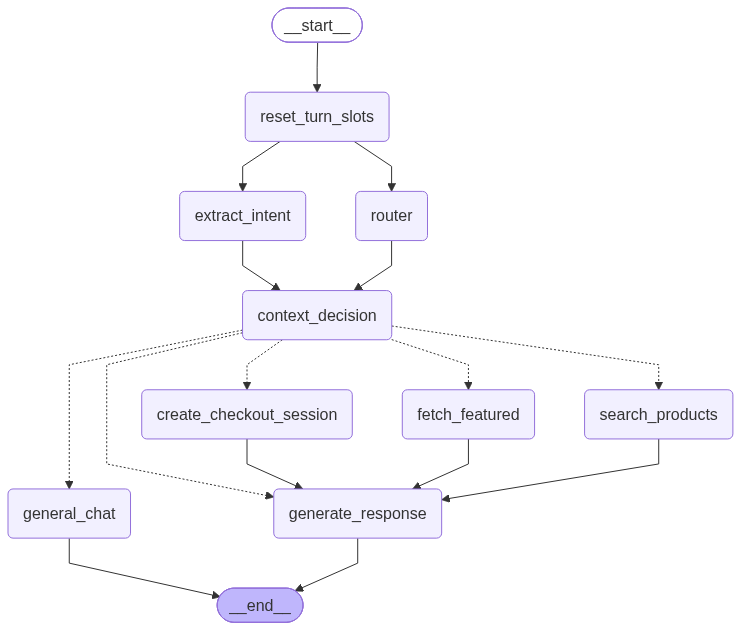

In [6]:
# Graph visualisation

import sys
# Ensure models module is registered for LangGraph Checkpointer
sys.modules['backend.models'] = sys.modules[__name__]
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from langchain_core.output_parsers import PydanticOutputParser
from typing import List, Optional, TypedDict
from pydantic import BaseModel, Field, field_validator
# from langgraph.checkpoint.serde.types import ERROR_ON_UNHANDLED
import warnings
warnings.filterwarnings("ignore", message=".*Deserializing unregistered type.*")
from enum import Enum

class RouteType(str, Enum):
    SHOPPING = "shopping"
    GENERAL = "general"


class ContextRoute(str, Enum):
    # Where should I get information from?
    SEARCH = "search"
    CONTEXT = "context"


class IntentType(str, Enum):
    SEARCH = "search"
    RECOMMEND = "recommend"
    DETAILS = "details"
    CHECKOUT = "checkout"
    GREETING = "greeting"
    GENERAL = "general"
    COMPARE = "compare"


class SizeOption(str, Enum):
    XS = "XS"
    S = "S"
    M = "M"
    L = "L"
    XL = "XL"
    XXL = "XXL"


class GenderOption(str, Enum):
    MALE = "male"
    FEMALE = "female"
    UNISEX = "unisex"


class SortOption(str, Enum):
    PRICE_ASC = "price_asc"
    PRICE_DESC = "price_desc"
    NEWEST = "newest"
    POPULAR = "popular"


class RouterModel(BaseModel):
    """
    Decide whether the query is a shopping query or a general query.
    """
    route: RouteType = Field(..., description="The route type for the query")


class ShoppingIntentModel(BaseModel):

    intent: IntentType = Field(..., description="Intent type for the shopping query")
    keyword: Optional[str] = Field(None, description="Raw search keywords or category names when explicit category is unlisted or null (e.g. 'dresses', 'polo', 'skirts').")
    category: Optional[str] = Field(None, description="Category of the shopping item")
    product_name: Optional[str] = Field(None, description="Name of the product")
    color: Optional[str] = Field(None, description="Color of the product")
    material: Optional[str] = Field(None, description="Material of the product")
    size: Optional[SizeOption] = Field(None, description="Size of the product")
    fit: Optional[str] = Field(None,description="Fit of the clothing such as Slim Fit, Regular Fit, Oversized, Relaxed Fit") 
    brands: Optional[List[str]] = Field(None, description="List of preferred brands for the product")
    gender: Optional[GenderOption] = Field(None, description="Target gender of the product")
    # price_range: Optional[str] = Field(None, description="Price range of the product")
    price_min: Optional[int] = Field(None, description="Minimum price of the product")
    price_max: Optional[int] = Field(None, description="Maximum price of the product")
    sort: Optional[SortOption] = Field(None, description="Sorting preference for the product")
    occasion: Optional[str] = Field(None, description="Occasion for the product")

# ==========================================================
# ADDITION FOR 8B MODEL COMPATIBILITY:
# 8B models sometimes output string "null" / "None" instead of JSON null.
# This pre-validator converts string "null" into Python None before Pydantic checks types.
# Works seamlessly for both 8B and 70B models.

# @field_validator("*", mode="before")
# def sanitize_string_nulls(cls, value):
#     if isinstance(value, str) and value.strip().lower() in ["null", "none", ""]:
#         return None
#     return value

#==================================================================

# Yeh ek temporary dictionary structured blueprint hai. 
# Har nayi turn ke shuru hote hi iske saare slots (category, keyword, color, etc.) 
# reset ho jate hain, taaki pichle turn ka out-of-stock topic next turn mein bleeding (leak) na kare.
class TurnSlots(TypedDict, total=False):
    """
    Ephemeral per-turn search slots — explicitly reset by the `reset_turn_slots`
    node at the start of every new user turn.
    Mirrors the search-relevant fields from ShoppingIntentModel so stale values
    (e.g. 'curtains' from a previous denial turn) can never bleed into the next turn.
    Persistent checkout context (active_focus_product, selected_product) is NOT here.
    """
    product_name: Optional[str]
    category: Optional[str]
    keyword: Optional[str]
    color: Optional[str]
    size: Optional[str]
    price_min: Optional[int]
    price_max: Optional[int]



class ShoppingState(TypedDict):
    query: str = Field(..., description="User's shopping query")
    route: RouteType | None = Field(None, description="ROUTER_PROMPT result")
    context_route: ContextRoute = Field(..., description="Where to get information from: search or context")
    intent: ShoppingIntentModel | None = Field(None, description="Extracted shopping intent from the query")
    products: List[dict] | None = Field(None, description="List of products matching the shopping intent")
    similar_products: List[dict] | None = Field(None, description="List of similar products for recommendations")
    selected_product: Optional[dict] = Field(None, description="The product selected by the user for details or checkout")
    payment_url: Optional[str] = Field(None, description="Payment URL for checkout if applicable")
    response: str | None = Field(None, description="Response to the user based on the shopping intent and products")
    displayed_products: List[dict] | None = Field(None, description="List of products to be displayed to the user in popup")
    # ── Dual-Layer State additions ────────────────────────────────────────────
    turn_slots: Optional[dict] = Field(None, description="Temporary search filters for the current query that reset every turn to prevent stale slot leakage.")
    active_focus_product: Optional[dict] = Field(None, description="The last successfully viewed product that stays saved across turns for multi-turn checkout context like 'buy that'.")
    last_bot_action: Optional[str] = Field(None, description="The bot's response signal from the previous turn ('showed_products' or 'offered_alternatives') used to route follow-up replies like 'yes' or 'show me'")

def reset_turn_slots(state: ShoppingState):
    pass
def router(state: ShoppingState):
    pass
def general_chat(state: ShoppingState):
    pass
def extract_intent(state: ShoppingState):
    pass
def search_product(state: ShoppingState):
    pass
def context_decision(state: ShoppingState):
    pass
def create_checkout_session(state: ShoppingState):
    pass
def generate_response(state: ShoppingState):
    pass
def fetch_featured(state: ShoppingState):
    pass
# ── GRAPH INITIALIZATION ──────────────────────────────────────────────────────
graph = StateGraph(ShoppingState)

# 1. ADD NODES
graph.add_node("reset_turn_slots", reset_turn_slots)      # Ephemeral slot reset pre-step
graph.add_node("router", router)
graph.add_node("general_chat", general_chat)
graph.add_node("extract_intent", extract_intent)
graph.add_node("context_decision", context_decision)
graph.add_node("search_products", search_product)
graph.add_node("create_checkout_session", create_checkout_session)
graph.add_node("generate_response", generate_response)
graph.add_node("fetch_featured", fetch_featured)          # Affirmative follow-up showcase node

# 2. STEP 1: SERIAL PRE-STEP (Reset ephemeral slots before routing/extraction)
graph.add_edge(START, "reset_turn_slots")

# STEP 2: PARALLEL FAN-OUT (Preserves speed & concurrency)
graph.add_edge("reset_turn_slots", "router")
graph.add_edge("reset_turn_slots", "extract_intent")

# STEP 3: PARALLEL FAN-IN INTO CONTEXT_DECISION
graph.add_edge("router", "context_decision")
graph.add_edge("extract_intent", "context_decision")


# ── PURE AI ROUTER GATE FUNCTION (ZERO MANUAL STRING MATCHING) ────────────────
def route_post_sync(state: ShoppingState) -> str:
    """
    Pure AI Gate Function:
    Rely strictly on Router LLM output, Intent extraction, and Bot Action Signals.
    No hardcoded frozensets, regex, or manual word matching!
    """
    route = state.get("route")
    route_str = str(getattr(route, "value", route) or "").lower()

    last_action = state.get("last_bot_action")

    # Safe extraction of extracted intent
    intent = state.get("intent")
    intent_type = getattr(intent, "intent", intent)
    intent_str = str(getattr(intent_type, "value", intent_type) or "").lower()

    print(f"[route_post_sync] route={route_str!r} | intent={intent_str!r} | last_action={last_action!r}")

    # 1. EVALUATE CHECKOUT INTENT (Highest Priority)
    if intent_str == "checkout":
        return "create_checkout_session"

    # 2. PURE AI AFFIRMATIVE FOLLOW-UP (No manual frozensets!)
    # If bot previously offered alternatives/denied AND the AI Router classified current turn as 'shopping'
    if last_action == "offered_alternatives" and route_str == "shopping":
        print("[route_post_sync] Pure AI Signal -> Branching to fetch_featured")
        return "fetch_featured"

    # 3. EVALUATE GENERAL / BANTER ROUTE
    if route_str == "general":
        return "general_chat"

    # 4. EVALUATE CONTEXT DECISION ROUTE
    context_route = state.get("context_route")
    context_str = str(getattr(context_route, "value", context_route) or "").lower()

    if context_str == "context":
        return "generate_response"

    # 5. DEFAULT SHOPPING FLOW
    return "search_products"


# 3. CONDITIONAL BRANCHING
graph.add_conditional_edges(
    "context_decision",
    route_post_sync,
    {
        "general_chat": "general_chat",
        "create_checkout_session": "create_checkout_session",
        "search_products": "search_products",
        "generate_response": "generate_response",
        "fetch_featured": "fetch_featured",
    }
)

# 4. TERMINAL EDGES
graph.add_edge("search_products", "generate_response")
graph.add_edge("create_checkout_session", "generate_response")
graph.add_edge("fetch_featured", "generate_response")
graph.add_edge("general_chat", END)
graph.add_edge("generate_response", END)

# 5. COMPILE GRAPH
memory = InMemorySaver()
workflow = graph.compile(checkpointer=memory)
workflow